# Proyecto de Clasificación de Nivel Socioeconómico (NSE)

### Importacion de librerias

In [1]:
# --- Manipulación y Análisis de Datos ---
# Para la manipulación y análisis de datos en DataFrames.
import pandas as pd  
# Para operaciones numéricas y manejo de arrays.
import numpy as np   

# --- Visualización de Datos ---
import matplotlib.pyplot as plt 

# --- Preprocesamiento y Modelado con Scikit-Learn ---

# Herramientas para dividir datos y optimizar modelos.
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
# Para manejar valores nulos.
from sklearn.impute import SimpleImputer 
# Para convertir etiquetas de texto a números.
from sklearn.preprocessing import LabelEncoder
# Para evaluar el rendimiento del modelo.
from sklearn.metrics import classification_report, ConfusionMatrixDisplay 

# --- Manejo de Desbalance de Clases con Imbalanced-Learn ---

# Para crear flujos de trabajo secuenciales (ej. SMOTE -> Modelo).
from imblearn.pipeline import Pipeline
# Técnica avanzada para balancear clases.
from imblearn.combine import SMOTETomek
# Técnica de sobremuestreo para generar datos sintéticos.
from imblearn.over_sampling import SMOTE         

# --- Algoritmo de Clasificación ---

# Modelo de Gradient Boosting de alto rendimiento.
from xgboost import XGBClassifier              

# --- Guardado y Carga del Modelo ---

# Para guardar y cargar el modelo entrenado de forma eficiente.
import joblib                                    

# --- Configuración Adicional ---

# Ignoramos warnings específicos para mantener la salida limpia.
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*X does not have valid feature names.*')

### Funciones Auxiliares

In [2]:
# Construcción de una función que realice el particionado completo
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

In [3]:
# Eliminar caracteristica Y y empaquetarla - copiar etiqueta X y empaquetarla
def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [4]:
def evaluate_result(y_pred, y, y_prep_pred, y_prep, metric):
    print(metric.__name__, "Sin preparación:", metric(y_pred, y, average='weighted'))
    print(metric.__name__, "Con preparación:", metric(y_prep_pred, y_prep, average='weighted'))

## Cargar datos formato excel

In [5]:
# Cargando archivos Xlsx
ruta_archivo = 'datasets.xlsx'
df = pd.read_excel(ruta_archivo)

In [6]:
# Configuramos opciones de visualización para ver todas las columnas del DataFrame.
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)

### Visualización de los datos

In [7]:
df.head(10)

,ENTREVISTADOR,REGISTRO,DC5_DC,DC7_DC_1_1,DC7_DC_1_2,...,URBANIZACION_RESIDEN,REGION,MUNICIPIO,NOMBRE,CIUDAD_RESIDENCIA
0,Autoadministrado sin contacto,1216,2,Otras ocupaciones,NaN,...,NaN,Capital,Sucre (Petare),NaN,NaN
1,Autoadministrado sin contacto,2685,2,NaN,NaN,...,27 DE FEBRERO,Capital,Plaza (Guarenas),JAIRO CABRERA,GUARENAS
2,Autoadministrado sin contacto,5167,2,Trabajadores por cuenta propia / Libre ejercic...,Trabajadores en el comercio informal,...,AVENIDA JUAN DE CASTELLANO. URBANIZACIÓN TARI...,Oriental,Marcano (Juan Griego),JUAN JOSE ADRIAN,JUANGRIEGO. NVA ESPARTA. ISLA DE MARGARITA
3,Autoadministrado sin contacto,5003,3,Patronos o empleadores (empresarios/ comercian...,Jubilados o con pensión venezolana,...,LOS ROBLES,Oriental,Maneiro (Pampatar),REYNALDO JAIME,MARGARITA
4,Autoadministrado sin contacto,5179,2,NaN,NaN,...,PUEBLO NUEVO,Centro Occidental,No sabe,EVA PERDOMO,ARAURE
5,Autoadministrado sin contacto,22,1,Patronos o empleadores (empresarios/ comercian...,NaN,...,NaN,Capital,Baruta (Baruta),NaN,NaN
6,Autoadministrado sin contacto,5259,2,Empleados de la empresa privada,NaN,...,LA LAGO,Zuliana,Maracaibo (Maracaibo),LILIBETH ROSALES,MARACAIBO
7,Autoadministrado sin contacto,4391,1,NaN,NaN,...,PARROQUIA UNARE,Guayana,Caroní (Ciudad Guayana),AIXA COROMOTO GÓMEZ AGUILERA,PUERTO ORDAZ
8,Autoadministrado sin contacto,5125,5,Trabajadores independientes en oficios calific...,NaN,...,NaN,Zuliana,Lagunillas (Ciudad Ojeda),CAROLINA MACHADO,NaN
9,Autoadministrado sin contacto,5126,3,Patronos o empleadores (empresarios/ comercian...,NaN,...,1 MAYO,Zuliana,Colón (San Carlos del Zulia),MARIA URDANETA,"SAN CARLOS, ZULIA/EL VIGÍA, MERIDA"


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ENTREVISTADOR         800 non-null    object 
 1   REGISTRO              800 non-null    int64  
 2   DC5_DC                800 non-null    int64  
 3   DC7_DC_1_1            661 non-null    object 
 4   DC7_DC_1_2            227 non-null    object 
 5   DC7_DC_1_3            58 non-null     object 
 6   DC7_DC_1_4            15 non-null     object 
 7   DC7_DC_1_5            5 non-null      object 
 8   DC7_DC_1_6            2 non-null      object 
 9   DC7_DC_1_7            1 non-null      object 
 10  DC7_DC_1_8            1 non-null      object 
 11  DC8_DC                800 non-null    int64  
 12  DC8_DC_18             800 non-null    int64  
 13  DC8_DC_M18            412 non-null    float64
 14  DC8_DC_T              800 non-null    int64  
 15  DC3_DC_1              8

In [9]:
df.describe()

,REGISTRO,DC5_DC,DC8_DC,DC8_DC_18,DC8_DC_M18,DC8_DC_T,SUMA
count,800.000000,800.000000,800.00000,800.000000,412.000000,800.00000,800.000000
mean,3196.750000,2.142500,3.84375,2.802500,2.021845,3.84375,3.501250
std,1956.909325,1.797563,1.90496,1.371439,1.230990,1.90496,2.158894
min,22.000000,1.000000,1.00000,1.000000,1.000000,1.00000,0.000000
25%,1084.250000,1.000000,3.00000,2.000000,1.000000,3.00000,2.000000
50%,3333.500000,2.000000,4.00000,3.000000,2.000000,4.00000,3.000000
75%,5149.250000,2.000000,5.00000,4.000000,3.000000,5.00000,5.000000
max,5342.000000,20.000000,16.00000,12.000000,15.000000,16.00000,11.000000


En esta sección visualizamos el numero de clases que hay en la variable objetiva

In [10]:
df['NSE'].value_counts()

NSE
E    371
D    323
C    106
Name: count, dtype: int64

La distribución que muestras (E: 371, D: 323, C: 106) no parece extremadamente desproporcionada en el sentido de que una clase sea minúscula y las otras gigantes. Sí hay un desequilibrio (C es significativamente más pequeña que E o D), pero no es de 1000 a 10.

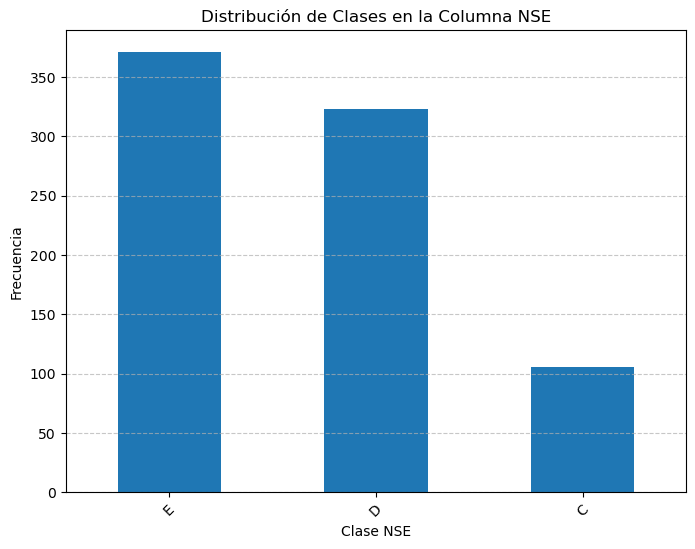

In [11]:
# Después de df['NSE'].value_counts()
plt.figure(figsize=(8, 6))
df['NSE'].value_counts().plot(kind='bar')
plt.title('Distribución de Clases en la Columna NSE')
plt.xlabel('Clase NSE')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
# Comprobación de si existen valores nulos
is_null = df.isna().any()
is_null[is_null]

DC7_DC_1_1              True
DC7_DC_1_2              True
DC7_DC_1_3              True
DC7_DC_1_4              True
DC7_DC_1_5              True
                        ... 
DC7_DC_1_8              True
DC8_DC_M18              True
URBANIZACION_RESIDEN    True
NOMBRE                  True
CIUDAD_RESIDENCIA       True
Length: 12, dtype: bool

In [13]:
# Comprobación de la existencia de valores infinitos
is_inf = df.isin([np.inf, -np.inf]).any()
is_inf[is_inf]

Series([], dtype: bool)

Confirmación de Valores Nulos: La fila count muestra un número de registros diferente para cada variable. Esto confirma lo que ya sabíamos: hay una cantidad variable de datos nulos en cada columna.

### Intuiciones
 <span style="color:green">¿Los valores se encuentran muy dispares?</span> Sí. Al comparar la media (mean) con la mediana (50%), se observa que en muchas columnas estos dos valores son diferentes. Por ejemplo, en la variable DC8_DC_T (total de personas en el hogar), la media es 4.4 y la mediana es 4.0. Aunque no es una diferencia abismal, indica un ligero sesgo.

<span style="color:green">En otras variables, esta diferencia puede ser mayor</span>. Cuando la media y la mediana difieren significativamente, es una señal clara de que la distribución de los datos está sesgada (asimétrica) y/o existen valores atípicos (outliers).

<span style="color:red">Eliminar Filas:</span> Si eliminas cada fila que tenga al menos un valor nulo, podrías terminar con una fracción muy pequeña de tu conjunto de datos original. Perderías muchísima información valiosa y el modelo resultante sería pobre.

<span style="color:green">¿Es la Mediana una Buena Estrategia de Imputación?</span>
Hhipotesis: preparar los datos cambiando los valores nulos por la mediana

La hipótesis es excelente y la más recomendada para tus datos numéricos.

### Imputación 

Dado que hemos visto que tus datos numéricos tienen sesgo y posibles valores atípicos (son "dispares"), la mediana es la mejor opción para la imputación por las siguientes razones:

Robustez ante Outliers: La mediana no se ve afectada por valores extremos, a diferencia de la media. Si en la variable "ingresos" tienes a una persona que gana 100 veces más que el resto, la media se disparará, pero la mediana seguirá representando el valor central de la población.
Mejor Representación del Centro: En una distribución asimétrica, la mediana es un mejor indicador del "valor típico" que la media.

Mejor Representación del Centro: En una distribución asimétrica, la mediana es un mejor indicador del "valor típico" que la media.
¿Qué pasa con las variables categóricas?
No puedes calcular la mediana de variables como DC7_DC_1_1 ("Ocupación"). Para estas, la estrategia estándar es imputar con la moda (el valor más frecuente).

Estrategia de Imputación Recomendada:

Para tus variables numéricas: Usa la mediana.
Para tus variables categóricas (de texto): Usa la moda (el valor más común).

### División del Conjunto de datos 60% 20% 20%
Vamos a usar Estratificación de los datos para mantener las proporciones homogeneas de la variable objetiva en cada conjunto de datos

In [14]:
# División del conjunto de datos
train_set, val_set, test_set = train_val_test_split(df)

In [15]:
X_train, y_train = remove_labels(train_set, 'NSE')
X_val, y_val = remove_labels(val_set, 'NSE')
X_test, y_test = remove_labels(test_set, 'NSE')

In [16]:
# Inicializamos el transformador para la imputación
imputer = SimpleImputer(strategy="median")

In [17]:
# Separamos las columnas númericas 
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Columnas Numéricas Identificadas:")
print(numeric_cols)
print("\nColumnas Categóricas Identificadas:")
print(categorical_cols)


Columnas Numéricas Identificadas:
['REGISTRO', 'DC5_DC', 'DC8_DC', 'DC8_DC_18', 'DC8_DC_M18', 'DC8_DC_T', 'SUMA']

Columnas Categóricas Identificadas:
['ENTREVISTADOR', 'DC7_DC_1_1', 'DC7_DC_1_2', 'DC7_DC_1_3', 'DC7_DC_1_4', 'DC7_DC_1_5', 'DC7_DC_1_6', 'DC7_DC_1_7', 'DC7_DC_1_8', 'DC3_DC_1', 'DC3_DC_2', 'DC3_DC_3', 'DC3_DC_4', 'DC3_DC_5', 'DC3_DC_6', 'DC3_DC_7', 'DC3_DC_8', 'DC3_DC_9', 'DC3_DC_10', 'DC3_DC_11', 'DC6_DC_P', 'DC4_DC', 'DC9_DC', 'DC10_DC', 'URBANIZACION_RESIDEN', 'REGION', 'MUNICIPIO', 'NOMBRE', 'CIUDAD_RESIDENCIA']


In [18]:
# ==============================================================================
#         INICIO DEL PLAN DE ACCIÓN: PREPROCESAMIENTO DE DATOS
# ==============================================================================

# --- PASO 1: SEPARAR COLUMNAS NUMÉRICAS Y CATEGÓRICAS ---
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Columnas Numéricas Identificadas:")
print(numeric_cols)
print("\nColumnas Categóricas Identificadas:")
print(categorical_cols)


# --- PASO 2: IMPUTAR VALORES NULOS (Estrategia Separada y Robusta) ---
X_train_prep = X_train.copy()
X_val_prep = X_val.copy()
X_test_prep = X_test.copy()

# 2.1) Imputación para variables NUMÉRICAS con la MEDIANA
imputer_numeric = SimpleImputer(strategy='median')
X_train_prep[numeric_cols] = imputer_numeric.fit_transform(X_train_prep[numeric_cols])
X_val_prep[numeric_cols] = imputer_numeric.transform(X_val_prep[numeric_cols])
X_test_prep[numeric_cols] = imputer_numeric.transform(X_test_prep[numeric_cols])

# 2.2) Imputación para variables CATEGÓRICAS con la MODA
# --- INICIO DE De LA FASE ---

# ANTES de imputar, convertimos todas las columnas categóricas a tipo 'string'.
# Esto previene el error 'NoneType' al estandarizar los datos.
for col in categorical_cols:
    X_train_prep[col] = X_train_prep[col].astype(str)
    X_val_prep[col] = X_val_prep[col].astype(str)
    X_test_prep[col] = X_test_prep[col].astype(str)
    
# --- FIN DEl PLAN DE ACCIÓN  ---

imputer_categorical = SimpleImputer(strategy='most_frequent')
X_train_prep[categorical_cols] = imputer_categorical.fit_transform(X_train_prep[categorical_cols])
X_val_prep[categorical_cols] = imputer_categorical.transform(X_val_prep[categorical_cols])
X_test_prep[categorical_cols] = imputer_categorical.transform(X_test_prep[categorical_cols])

print("\n¡Imputación de valores nulos completada!")


# --- PASO 3: CODIFICAR VARIABLES CATEGÓRICAS (One-Hot Encoding O Get_dummies) ---
# Ahora el valor que antes era nulo (ej: 'nan' o 'None') será tratado como una categoría más.
X_train_encoded = pd.get_dummies(X_train_prep, columns=categorical_cols, drop_first=True)
X_val_encoded = pd.get_dummies(X_val_prep, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_prep, columns=categorical_cols, drop_first=True)

# Alinear columnas para asegurar que todos los dataframes tengan las mismas dimensiones
X_train_final, X_val_final = X_train_encoded.align(X_val_encoded, join='left', axis=1, fill_value=0)
X_train_final, X_test_final = X_train_final.align(X_test_encoded, join='left', axis=1, fill_value=0)

X_val_final = X_val_final.fillna(0)
X_test_final = X_test_final.fillna(0)


print("\n¡Codificación One-Hot Get Dummies completada y columnas alineadas!")
print("Dimensiones de los datos finales:")
print("X_train_final:", X_train_final.shape)
print("X_val_final:", X_val_final.shape)
print("X_test_final:", X_test_final.shape)

# ==============================================================================
# FIN DEL PLAN DE ACCIÓN
# ==============================================================================

Columnas Numéricas Identificadas:
['REGISTRO', 'DC5_DC', 'DC8_DC', 'DC8_DC_18', 'DC8_DC_M18', 'DC8_DC_T', 'SUMA']

Columnas Categóricas Identificadas:
['ENTREVISTADOR', 'DC7_DC_1_1', 'DC7_DC_1_2', 'DC7_DC_1_3', 'DC7_DC_1_4', 'DC7_DC_1_5', 'DC7_DC_1_6', 'DC7_DC_1_7', 'DC7_DC_1_8', 'DC3_DC_1', 'DC3_DC_2', 'DC3_DC_3', 'DC3_DC_4', 'DC3_DC_5', 'DC3_DC_6', 'DC3_DC_7', 'DC3_DC_8', 'DC3_DC_9', 'DC3_DC_10', 'DC3_DC_11', 'DC6_DC_P', 'DC4_DC', 'DC9_DC', 'DC10_DC', 'URBANIZACION_RESIDEN', 'REGION', 'MUNICIPIO', 'NOMBRE', 'CIUDAD_RESIDENCIA']

¡Imputación de valores nulos completada!

¡Codificación One-Hot Get Dummies completada y columnas alineadas!
Dimensiones de los datos finales:
X_train_final: (480, 1297)
X_val_final: (160, 1297)
X_test_final: (160, 1297)


In [19]:
#Visualizamos el conjunto final
X_train_final

,REGISTRO,DC5_DC,DC8_DC,DC8_DC_18,DC8_DC_M18,...,CIUDAD_RESIDENCIA_YARITAGUA,CIUDAD_RESIDENCIA_ZARAZA,CIUDAD_RESIDENCIA_ZULIA,CIUDAD_RESIDENCIA_ZULIA JESÚS MARÍA SEMPRÚN. CASIGUA EL CUBO,CIUDAD_RESIDENCIA_nan
766,873.0,2.0,6.0,2.0,4.0,...,False,False,False,False,False
257,3434.0,1.0,1.0,1.0,2.0,...,False,False,False,False,False
765,5143.0,1.0,7.0,7.0,2.0,...,False,False,False,False,False
543,1747.0,2.0,3.0,3.0,2.0,...,False,False,False,False,False
15,5165.0,2.0,5.0,3.0,2.0,...,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
71,5042.0,2.0,3.0,3.0,2.0,...,False,False,False,False,False
106,1264.0,2.0,2.0,2.0,2.0,...,False,False,False,False,True
270,5282.0,1.0,3.0,2.0,1.0,...,False,False,False,False,False
435,2558.0,2.0,3.0,3.0,2.0,...,False,False,False,False,False


## Intuiciones

¿Por qué aumentó tanto el número de columnas (de ~30 a 203)?
Esto se debe al One-Hot Encoding (pd.get_dummies). Recuerda que los algoritmos como Random Forest no entienden texto ("Casado", "Apartamento", etc.), solo entienden números.

Lo que hace One-Hot Encoding es tomar una columna categórica y crear nuevas columnas numéricas para cada una de sus categorías.

Imagina que tu columna DC10_DC (Tipo de vivienda) tiene 3 categorías: "Casa", "Apartamento" y "Rancho".

Antes de la codificación: Tenías 1 columna (DC10_DC).
Después de get_dummies: El código transforma esa columna en 2 nuevas columnas (usamos drop_first=True para eliminar una y evitar redundancia):
| DC10_DC (Original) | → | DC10_DC_Apartamento | DC10_DC_Rancho |
| :--- | :-: | :---: | :---: |
| "Casa" | → | 0 | 0 |
| "Apartamento" | → | 1 | 0 |
| "Rancho" | → | 0 | 1 |

El código hizo este proceso para todas tus columnas categóricas (DC7_DC_1_1, DC9_DC, etc.). La suma de tus columnas numéricas originales más todas estas nuevas columnas creadas da como resultado las 203 columnas finales.

¿Qué significa (480, 203)?
Esto representa la dimensión (shape) de tu conjunto de datos de entrenamiento final:

480 filas: El 60% de tus datos originales, que se usarán para que el modelo aprenda.
203 columnas: Las características (features) que el modelo usará para aprender a predecir el NSE. Todas son 100% numéricas.
¿Y qué es eso de "Columnas Alineadas"?
Es un paso de seguridad crucial. A veces, el conjunto de validación (X_val) puede no tener una categoría que sí está en el de entrenamiento (X_train). Si no las alineamos, X_train podría tener 203 columnas y X_val 201, lo que daría un error. El comando .align() asegura que los tres conjuntos de datos (train, val y test) tengan exactamente las mismas 203 columnas en el mismo orden, rellenando con 0 si alguna falta.

### Valores Booleanos?

<span style="color:green">¿El Modelo Entiende los Valores Booleanos</span> (True/False)?
y una pregunta el modelo entinede esos valores booleanos que dicen false?

La respuesta es: Sí, perfectamente.

Esta es una excelente observación. Al ver dtype: bool en la imagen, es normal preguntarse si el modelo puede manejarlo.

En el mundo de la computación y de librerías como pandas y scikit-learn, los valores booleanos son tratados matemáticamente como números enteros:

True se interpreta como 1.
False se interpreta como 0.

### Convertir nuestra variable objetiva a númerica con la tecnica de Encoding

<span style="color:blue">Cómo Funciona LabelEncoder?</span>
Es muy sencillo. LabelEncoder toma una columna con etiquetas de texto y hace dos cosas:

Encuentra todas las categorías únicas (en tu caso, 'C', 'D', 'E').
Asigna un número entero a cada una (por ejemplo: 'C' → 0, 'D' → 1, 'E' → 2).
Una gran ventaja es que el LabelEncoder "recuerda" este mapeo, por lo que más tarde, cuando tu modelo prediga un 1, puedes usar el mismo codificador para que te diga que la predicción real es 'D'.

In [20]:
# Creamos una instancia del LabelEncoder
label_encoder = LabelEncoder()

In [21]:
# Ajustamos el codificador y transformamos y_train. 
# El .fit() aprende la relación ('C'->0, 'D'->1, etc.) y .transform() la aplica.
y_train_encoded = label_encoder.fit_transform(y_train)

In [22]:
# Para los conjuntos de validación y prueba, SÓLO transformamos,
# ya que deben usar el mismo mapeo aprendido de y_train.
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

In [23]:
# (Opcional pero muy recomendado) Verifiquemos el mapeo que ha creado
print("Mapeo de la variable objetivo 'NSE':")
mapeo_clases = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(mapeo_clases)

# Por ejemplo, la salida podría ser: {'C': 0, 'D': 1, 'E': 2}

Mapeo de la variable objetivo 'NSE':
{'C': 0, 'D': 1, 'E': 2}


### --- FIN DEL PREPROCESAMIENTO --- 

Considerar class_weight='balanced' en tu RandomForestClassifier para que el algoritmo dé más peso a las clases minoritarias. ya que las clases se encuentran ligeramente en desbalance Técnicas de oversampling (ej. SMOTE) o undersampling (ej. NearMiss) para balancear el dataset antes del entrenamiento.
Usar métricas de evaluación adecuadas para clases desbalanceadas (F1-score, Recall, Precision por clase, Matriz de Confusión)


## Algoritmo Random Forests¶

Al estar dispuesto a invertir tiempo computacional, podemos usar las técnicas más exhaustivas para encontrar la mejor configuración posible.

La rejilla de parametross (manejar desbalanceo y encontrar los mejores hiperparámetros sin importar el tiempo), la estrategia definitiva es usar GridSearchCV junto con Cross-Validation.

### Aplicación

Probará Exhaustivamente: Le daremos una "rejilla" (un diccionario) con todos los hiperparámetros que quieres probar para RandomForestClassifier. GridSearchCV entrenará un modelo para cada combinación posible de estos parámetros.

Manejará el Desbalanceo: Incluiremos el parámetro class_weight dentro de la rejilla. De esta forma, la búsqueda no solo encontrará la mejor combinación de número de árboles o profundidad, sino que también determinará si el modelo funciona mejor con el peso de clases balanceado, o sin él.

Usará Validación Cruzada (CV): Para evitar el azar y asegurar que los resultados sean robustos, GridSearchCV divide los datos de entrenamiento en varias partes (por ejemplo, 5 "folds"). Entrena el modelo en 4 partes y lo valida en la 5ta, repitiendo el proceso 5 veces. La puntuación final de cada combinación de hiperparámetros es el promedio de estas 5 validaciones.

Optimizará para la Métrica Correcta: Lo configuraremos para que su único objetivo sea maximizar el F1-Score ponderado, que es la métrica ideal para el problema de clases desbalanceadas.

Al final, te entregará la combinación de hiperparámetros que obtuvo el mejor F1-Score promedio.

#### 3.2. Verificaciones Previas y Configuración Dinámica
*Antes de configurar el pipeline, realizamos una verificación crucial: contamos las muestras de la clase minoritaria para definir un valor seguro para el parámetro `k_neighbors` de SMOTE. Esto previene errores durante la validación cruzada.*

In [24]:
# Importamos RandomizedSearchCV desde scikit-learn
from sklearn.model_selection import RandomizedSearchCV

In [25]:
print("--- Verificaciones de Datos de Entrenamiento ---")
class_counts = pd.Series(y_train_encoded).value_counts()
min_samples_in_minority_class = class_counts.min()
smote_k_neighbors_base = min(min_samples_in_minority_class - 1, 5)
if smote_k_neighbors_base < 1: smote_k_neighbors_base = 1

print(f"Número mínimo de muestras en la clase minoritaria: {min_samples_in_minority_class}")
print(f"Valor seguro de k_neighbors para SMOTE: {smote_k_neighbors_base}")
print("--------------------------------------------------\n")

--- Verificaciones de Datos de Entrenamiento ---
Número mínimo de muestras en la clase minoritaria: 56
Valor seguro de k_neighbors para SMOTE: 5
--------------------------------------------------



#### 3.3. Definición del Pipeline y la Rejilla de Búsqueda
*Creamos un `pipeline` que primero aplicará el balanceo con `SMOTETomek` y luego entrenará el clasificador `XGBClassifier`. También definimos un diccionario (`param_dist`) con un rango amplio de hiperparámetros para explorar.*

In [26]:
# Definimos el pipeline de dos pasos
pipeline = Pipeline([
    ('sampling', SMOTETomek(random_state=42, smote=SMOTE(k_neighbors=smote_k_neighbors_base, random_state=42))),
    ('classifier', XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False, n_jobs=1))
])

# Definimos la rejilla amplia de hiperparámetros para la búsqueda aleatoria
param_dist = {
    'classifier__n_estimators': [200, 400, 600, 800, 1000],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'classifier__max_depth': [3, 5, 7, 9, 11],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'classifier__reg_alpha': [0, 0.001, 0.01, 0.1, 1],
    'classifier__reg_lambda': [1, 0.1, 0.01, 0.001]
}

#### 3.4. Configuración y Ejecución de la Búsqueda Aleatoria
*Configuramos `RandomizedSearchCV` para que pruebe 100 combinaciones aleatorias de la rejilla anterior. Este es el paso que consume más tiempo y recursos computacionales. La validación cruzada estratificada (`StratifiedKFold`) asegura que cada "fold" de la evaluación mantenga la proporción de clases original.*

In [27]:
# Definimos la estrategia de validación cruzada segura
n_splits_safe = min(min_samples_in_minority_class, 5)
cv_strategy = StratifiedKFold(n_splits=n_splits_safe, shuffle=True, random_state=42)

# Configuramos la búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=100, # ¡LA CLAVE! Número de combinaciones a probar.
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2,
    scoring='f1_weighted',
    random_state=42,
    error_score='raise'
)

print(f"\n¡ATENCIÓN! Iniciando búsqueda ALEATORIA de {random_search.n_iter} combinaciones.")
# Ejecutamos la búsqueda
random_search.fit(X_train_final, y_train_encoded)


¡ATENCIÓN! Iniciando búsqueda ALEATORIA de 100 combinaciones.
Fitting 5 folds for each of 100 candidates, totalling 500 fits


C:\Users\roome\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\roome\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\roome\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\roome\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\roome\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _wina

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   error_score='raise',
                   estimator=Pipeline(steps=[('sampling',
                                              SMOTETomek(random_state=42,
                                                         smote=SMOTE(random_state=42))),
                                             ('classifier',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            earl...
                                        'classifier__gamma': [0, 0.1, 0.2, 0.3,
                                                              0.4],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05, 0.1,
                                                                      0.15,
                                                                      0.2],
                                        'classifier__max_depth': [3, 5, 7, 9,
                                                                  11],
                                        'classifier__n_estimators': [200, 400,
                                                                     600, 800,
                                                                     1000],
                                        'classifier__reg_alpha': [0, 0.001,
                                                                  0.01, 0.1,
                                                                  1],
                                        'classifier__reg_lambda': [1, 0.1, 0.01,
                                                                   0.001],
                                        'classifier__subsample': [0.6, 0.7, 0.8,
                                                                  0.9, 1.0]},
                   random_state=42, scoring='f1_weighted', verbose=2)

#### 3.5. Análisis de Resultados de la Búsqueda
*Una vez completada la búsqueda, extraemos los resultados para identificar la mejor combinación de hiperparámetros y el rendimiento promedio que se obtuvo durante la validación cruzada.*

In [28]:
print("\n¡Búsqueda aleatoria completada!")
print("\nLos mejores hiperparámetros encontrados son:")
print(random_search.best_params_)

print("\nMejor F1-Score (ponderado) en validación cruzada:")
print(random_search.best_score_)

# Guardamos el mejor pipeline encontrado. Este es nuestro mejor modelo de esta fase.
best_pipeline = random_search.best_estimator_


¡Búsqueda aleatoria completada!

Los mejores hiperparámetros encontrados son:
{'classifier__subsample': 0.9, 'classifier__reg_lambda': 0.01, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 1000, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0.1, 'classifier__colsample_bytree': 1.0}

Mejor F1-Score (ponderado) en validación cruzada:
0.8628095278419838


#### 3.6. Evaluación Final del Mejor Modelo en Datos de Prueba
*Este es el veredicto final de esta fase. Evaluamos el mejor modelo encontrado contra el conjunto de prueba (`X_test_final`), que son datos que el modelo nunca ha visto, para obtener una estimación real de su rendimiento.*


--- Evaluación del Mejor Modelo (Búsqueda Amplia) en el Conjunto de Prueba ---
              precision    recall  f1-score   support

           C       0.92      0.79      0.85        28
           D       0.83      0.87      0.85        60
           E       0.92      0.93      0.92        72

    accuracy                           0.88       160
   macro avg       0.89      0.86      0.87       160
weighted avg       0.88      0.88      0.88       160


Matriz de Confusión:


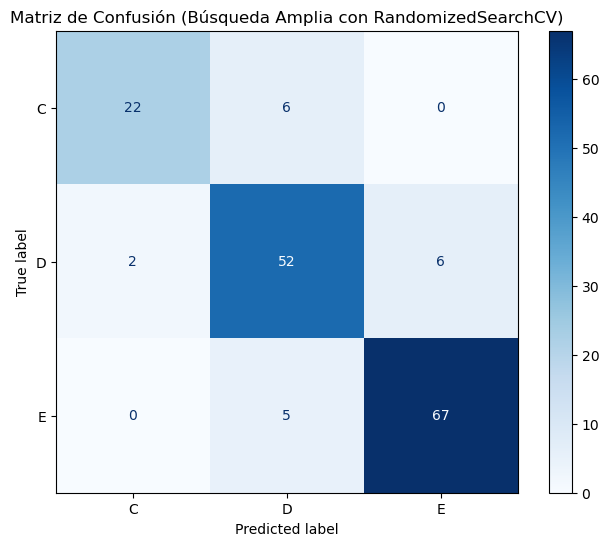

In [29]:
print("\n--- Evaluación del Mejor Modelo (Búsqueda Amplia) en el Conjunto de Prueba ---")
y_pred_test = best_pipeline.predict(X_test_final)

# Imprimimos el reporte de clasificación con las métricas clave (precision, recall, f1-score)
print(classification_report(y_test_encoded, y_pred_test, target_names=label_encoder.classes_))

# Visualizamos la Matriz de Confusión para entender los aciertos y errores por clase.
print("\nMatriz de Confusión:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_pipeline, X_test_final, y_test_encoded,
                                      display_labels=label_encoder.classes_,
                                      cmap=plt.cm.Blues,
                                      ax=ax)
plt.title("Matriz de Confusión (Búsqueda Amplia con RandomizedSearchCV)")
plt.show()

### 4. Fase de Afinamiento Final con GridSearchCV
*Ahora que conocemos la "región" de hiperparámetros más prometedora gracias a la búsqueda aleatoria, realizamos una búsqueda de rejilla (`GridSearchCV`) mucho más pequeña y enfocada. El objetivo es exprimir hasta la última gota de rendimiento, probando de forma exhaustiva solo los valores más cercanos al óptimo encontrado.*

#### 4.1. Definición de la Rejilla de Afinamiento
*Creamos una nueva rejilla de parámetros (`param_grid_final_tuning`) muy específica. Nos centramos en los 3 o 4 hiperparámetros más influyentes (`n_estimators`, `learning_rate`, `max_depth`) y probamos valores muy cercanos a los que `RandomizedSearchCV` nos indicó como los mejores. Los demás parámetros los mantenemos fijos en su valor óptimo ya encontrado.*

In [30]:
# Importamos GridSearchCV, ya que ahora usaremos la búsqueda exhaustiva
from sklearn.model_selection import GridSearchCV

# Comentamos los mejores parámetros de la fase anterior como referencia
# 'subsample': 0.9, 'reg_lambda': 0.01, 'reg_alpha': 0, 'n_estimators': 1000, 
# 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0

print("--- Iniciando la fase de Afinamiento Final ---")

--- Iniciando la fase de Afinamiento Final ---


In [31]:
# Creamos la rejilla pequeña y específica para el afinamiento
param_grid_final_tuning = {
    'classifier__n_estimators': [900, 1000, 1100],      # Alrededor de 1000
    'classifier__learning_rate': [0.008, 0.01, 0.015],   # Alrededor de 0.01
    'classifier__max_depth': [2, 3, 4],                  # Alrededor de 3
    
    # Mantenemos los siguientes parámetros fijos en su mejor valor encontrado
    'classifier__subsample': [0.9],
    'classifier__colsample_bytree': [1.0],
    'classifier__gamma': [0.1],
    'classifier__reg_alpha': [0],
    'classifier__reg_lambda': [0.01]
}

#### 4.2. Configuración y Ejecución de la Búsqueda Fina
*Configuramos `GridSearchCV` con el mismo pipeline y estrategia de validación cruzada. Como la rejilla es muy pequeña, esta búsqueda será mucho más rápida que la anterior.*

In [32]:
# Configuramos la búsqueda de rejilla
final_grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid_final_tuning,
    cv=cv_strategy, # Usamos la misma cv_strategy segura
    n_jobs=-1,
    verbose=2,
    scoring='f1_weighted'
)

print("\nIniciando búsqueda de afinamiento final...")
# Ejecutamos la búsqueda
final_grid_search.fit(X_train_final, y_train_encoded)


Iniciando búsqueda de afinamiento final...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Users\roome\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:32:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sampling',
                                        SMOTETomek(random_state=42,
                                                   smote=SMOTE(random_state=42))),
                                       ('classifier',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      ena...
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__colsample_bytree': [1.0],
                         'classifier__gamma': [0.1],
                         'classifier__learning_rate': [0.008, 0.01, 0.015],
                         'classifier__max_depth': [2, 3, 4],
                         'classifier__n_estimators': [900, 1000, 1100],
                         'classifier__reg_alpha': [0],
                         'classifier__reg_lambda': [0.01],
                         'classifier__subsample': [0.9]},
             scoring='f1_weighted', verbose=2)

#### 4.3. Análisis de Resultados del Modelo Definitivo
*Una vez completada la búsqueda fina, extraemos y evaluamos el modelo final. Este representa el mejor rendimiento que hemos podido alcanzar con la configuración actual.*

In [33]:
print("\n¡Afinamiento final completado!")

print("\nLos hiperparámetros definitivos y óptimos son:")
print(final_grid_search.best_params_)

print("\nMejor F1-Score (ponderado) en validación cruzada tras el afinamiento:")
print(final_grid_search.best_score_)

# Este es nuestro modelo final, listo para producción
final_best_model = final_grid_search.best_estimator_

# Evaluamos su rendimiento en el conjunto de prueba
print("\n--- Evaluación del Modelo Definitivo en el Conjunto de Prueba ---")
y_pred_final = final_best_model.predict(X_test_final)

print(classification_report(y_test_encoded, y_pred_final, target_names=label_encoder.classes_))


¡Afinamiento final completado!

Los hiperparámetros definitivos y óptimos son:
{'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0.1, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 1100, 'classifier__reg_alpha': 0, 'classifier__reg_lambda': 0.01, 'classifier__subsample': 0.9}

Mejor F1-Score (ponderado) en validación cruzada tras el afinamiento:
0.8629040397663077

--- Evaluación del Modelo Definitivo en el Conjunto de Prueba ---
              precision    recall  f1-score   support

           C       0.96      0.82      0.88        28
           D       0.84      0.88      0.86        60
           E       0.92      0.93      0.92        72

    accuracy                           0.89       160
   macro avg       0.91      0.88      0.89       160
weighted avg       0.90      0.89      0.89       160



## Visualizamos la Martiz de Confusión Final


Matriz de Confusión del Modelo Definitivo:


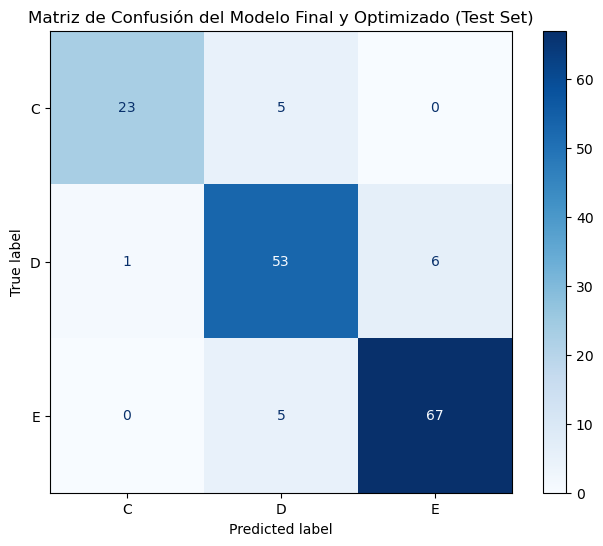

In [34]:
# Visualizamos la Matriz de Confusión final
print("\nMatriz de Confusión del Modelo Definitivo:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(final_best_model, X_test_final, y_test_encoded,
                                      display_labels=label_encoder.classes_,
                                      cmap=plt.cm.Blues,
                                      ax=ax)
plt.title("Matriz de Confusión del Modelo Final y Optimizado (Test Set)")
plt.show()

### 5. Exportación del Modelo para Despliegue
*Ahora que tenemos nuestro modelo definitivo (`final_best_model`), completamente optimizado y validado, el siguiente paso es guardarlo en un único archivo. Esto nos permitirá cargarlo en otros entornos (como una aplicación, una API o para análisis futuros) y hacer predicciones de forma instantánea.*

In [35]:
# Definimos el nombre del archivo para nuestro modelo
nombre_archivo_modelo = 'datanalisis_model_final.joblib'

# Usamos joblib.dump para guardar nuestro pipeline completo en el archivo especificado
joblib.dump(final_best_model, nombre_archivo_modelo)

print(f"¡Éxito! Modelo final guardado como: '{nombre_archivo_modelo}'")
print("Este archivo ahora contiene todo el pipeline (SMOTE + XGBoost con los mejores parámetros).")

¡Éxito! Modelo final guardado como: 'datanalisis_model_final.joblib'
Este archivo ahora contiene todo el pipeline (SMOTE + XGBoost con los mejores parámetros).


### 6. Ejemplo de Carga y Uso del Modelo Guardado
*Este bloque final simula cómo un sistema diferente cargaría tu modelo desde el archivo `.joblib` y lo usaría para clasificar un nuevo registro. Este es el primer paso para un despliegue local o en producción.*

In [36]:
# --- 1. Cargar el modelo desde el archivo ---
print(f"Cargando el modelo guardado desde '{nombre_archivo_modelo}'...")
modelo_cargado = joblib.load(nombre_archivo_modelo)
print("Modelo cargado exitosamente en la variable 'modelo_cargado'.")


# --- 2. Simulación de un nuevo dato para predecir ---
# Usaremos la primera fila de nuestro conjunto de prueba como ejemplo.
# ¡IMPORTANTE! Cualquier dato nuevo que quieras predecir debe tener exactamente
# la misma estructura (mismas 203 columnas en el mismo orden) que X_train_final.
nuevo_dato = X_test_final.iloc[[0]] 


# --- 3. Realizar una predicción con el modelo cargado ---
prediccion_numerica = modelo_cargado.predict(nuevo_dato)
prediccion_probabilidades = modelo_cargado.predict_proba(nuevo_dato)


# --- 4. Interpretar el resultado ---
# El modelo predice la clase en formato numérico (ej. 0, 1, 2).
# Usamos el 'label_encoder' que ya teníamos para revertir el número a la etiqueta de texto original.
prediccion_etiqueta = label_encoder.inverse_transform(prediccion_numerica)


print(f"\n--- PREDICCIÓN PARA EL NUEVO DATO ---")
print(f" -> Etiqueta Predicha: {prediccion_etiqueta[0]}")
print(f" -> Probabilidades por Clase (en el orden {label_encoder.classes_}): {np.round(prediccion_probabilidades[0], 3)}")

Cargando el modelo guardado desde 'datanalisis_model_final.joblib'...
Modelo cargado exitosamente en la variable 'modelo_cargado'.

--- PREDICCIÓN PARA EL NUEVO DATO ---
 -> Etiqueta Predicha: D
 -> Probabilidades por Clase (en el orden ['C' 'D' 'E']): [0.003 0.978 0.019]


## Fin  Verificando el Dato Original de la Predicción
*Para entender por qué el modelo hizo una predicción específica (ej. 'D' con 97.8% de probabilidad), es útil visualizar los datos originales de ese registro. Rastrearemos el `nuevo_dato` hasta su origen en el `test_set` para ver sus características legibles por un humano.*

In [37]:
print("--- Mostrando los datos originales del registro utilizado para la predicción ---")
print("Este es el 'perfil' de la persona/hogar que el modelo clasificó como 'D'.")

# `nuevo_dato` fue creado a partir de la primera fila de X_test_final,
# que a su vez corresponde a la primera fila del `test_set` original.
# Usamos .T (Transponer) para ver la fila como una lista vertical, que es mucho más fácil de leer.

registro_original = test_set.iloc[[0]].T
registro_original.columns = ['Valor Original del Registro'] # Renombramos la columna para mayor claridad

# También vamos a ver cuál era la etiqueta REAL de este registro para comparar
etiqueta_real = y_test.iloc[0]
print(f"\nLa etiqueta REAL de este registro era: '{etiqueta_real}'")
print(f"La etiqueta PREBICHA por el modelo fue: '{prediccion_etiqueta[0]}'")


print("\n--- Características del Registro ---")
# Imprimimos la tabla transpuesta
print(registro_original)

--- Mostrando los datos originales del registro utilizado para la predicción ---
Este es el 'perfil' de la persona/hogar que el modelo clasificó como 'D'.

La etiqueta REAL de este registro era: 'D'
La etiqueta PREBICHA por el modelo fue: 'D'

--- Características del Registro ---
                                    Valor Original del Registro
ENTREVISTADOR                     Autoadministrado sin contacto
REGISTRO                                                   5304
DC5_DC                                                        2
DC7_DC_1_1            Trabajadores en la administración pública
DC7_DC_1_2                                    Otras ocupaciones
...                                                         ...
URBANIZACION_RESIDEN                            SECTOR LA CALLE
REGION                                                Los Andes
MUNICIPIO                                     Escuque (Escuque)
NOMBRE                                             EMMY BRICEÑO
CIUDAD_RESIDENC

In [38]:
import joblib

# Define el nombre del archivo para guardar tu modelo
# Es buena práctica incluir el nombre del proyecto y el tipo de modelo
nombre_archivo_modelo = 'datanalisis_model_final.joblib'

# Guarda el modelo (en este caso, tu pipeline completo) en el archivo especificado
joblib.dump(final_best_model, nombre_archivo_modelo)

print(f"¡Éxito! Modelo final guardado como: '{nombre_archivo_modelo}'")
print("Este archivo ahora contiene todo el pipeline (preprocesamiento + modelo con los mejores parámetros).")

¡Éxito! Modelo final guardado como: 'datanalisis_model_final.joblib'
Este archivo ahora contiene todo el pipeline (preprocesamiento + modelo con los mejores parámetros).


In [39]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings

# Ignoramos warnings para una salida más limpia
warnings.filterwarnings('ignore', category=UserWarning, message='.X does not have valid feature names.')

# --- PASO 1: CARGAR DATOS ---
print("Cargando el archivo 'datasets.xlsx'...")
ruta_archivo = 'datasets.xlsx'
df_original = pd.read_excel(ruta_archivo)
print(f"Se cargaron {len(df_original)} registros.")

# Creamos una copia para el preprocesamiento, manteniendo el original intacto
df_procesar = df_original.copy()

# --- PASO 2: PREPROCESAMIENTO COMPLETO DE LOS DATOS ---
print("\nIniciando el preprocesamiento de todos los datos...")

# Separamos las características (X) de la etiqueta original (y)
# Aunque entrenaremos con 'y', la separamos para mantener la estructura
X = df_procesar.drop('NSE', axis=1)
y = df_procesar['NSE'].copy()

# 2.1) Separar columnas numéricas y categóricas
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Se identificaron {len(numeric_cols)} columnas numéricas y {len(categorical_cols)} categóricas.")

# 2.2) Imputar valores nulos
# Para numéricas, usamos la mediana (robusta a outliers)
imputer_numeric = SimpleImputer(strategy='median')
X[numeric_cols] = imputer_numeric.fit_transform(X[numeric_cols])

# Para categóricas, usamos la moda (el valor más frecuente)
# Convertimos todas a string primero para evitar errores
for col in categorical_cols:
    X[col] = X[col].astype(str)
imputer_categorical = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = imputer_categorical.fit_transform(X[categorical_cols])
print("Imputación de valores nulos completada.")

# 2.3) Codificar variables categóricas (One-Hot Encoding)
X_final = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"Codificación One-Hot completada. El número final de características es: {X_final.shape[1]}")

# 2.4) Codificar la variable objetivo 'NSE' a formato numérico
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Variable objetivo 'NSE' codificada a números.")

# --- PASO 3: ENTRENAMIENTO DEL NUEVO MODELO (RandomForest) ---
print("\nEntrenando el modelo RandomForestClassifier con el 100% de los datos...")

# Creamos el modelo RandomForest.
# Usamos class_weight='balanced' para manejar el desequilibrio de clases que vimos en el análisis.
# n_estimators=200 es un buen punto de partida.
modelo_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced', # Importante para clases desbalanceadas
    n_jobs=-1 # Usa todos los procesadores disponibles
)

# Entrenamos el modelo con todos los datos preprocesados
modelo_final.fit(X_final, y_encoded)
print("¡Modelo entrenado exitosamente!")

# --- PASO 4: REALIZAR PREDICCIONES EN TODO EL CONJUNTO DE DATOS ---
print("\nRealizando predicciones para todos los encuestados...")
predicciones_numericas = modelo_final.predict(X_final)

# Revertimos las predicciones numéricas a sus etiquetas originales (ej: 0 -> 'C')
predicciones_etiquetas = label_encoder.inverse_transform(predicciones_numericas)
print("Predicciones generadas y decodificadas a sus etiquetas originales.")

# --- PASO 5: AGREGAR PREDICCIONES AL DATAFRAME ORIGINAL ---
df_original['NSE_Prediccion'] = predicciones_etiquetas
print("Nueva columna 'NSE_Prediccion' agregada al DataFrame original.")

# --- PASO 6: GUARDAR EL RESULTADO FINAL ---
nombre_archivo_salida = 'Encuestados_con_Prediccion.csv'
df_original.to_csv(nombre_archivo_salida, index=False, encoding='utf-8-sig')
print(f"\n¡Proceso completado! Los resultados se han guardado en el archivo: '{nombre_archivo_salida}'")

# Mostramos las primeras filas del resultado final
print("\nVista previa del resultado final:")
print(df_original[['REGISTRO', 'NOMBRE', 'NSE', 'NSE_Prediccion']].head())

Cargando el archivo 'datasets.xlsx'...
Se cargaron 800 registros.

Iniciando el preprocesamiento de todos los datos...
Se identificaron 7 columnas numéricas y 29 categóricas.
Imputación de valores nulos completada.
Codificación One-Hot completada. El número final de características es: 1968
Variable objetivo 'NSE' codificada a números.

Entrenando el modelo RandomForestClassifier con el 100% de los datos...
¡Modelo entrenado exitosamente!

Realizando predicciones para todos los encuestados...
Predicciones generadas y decodificadas a sus etiquetas originales.
Nueva columna 'NSE_Prediccion' agregada al DataFrame original.

¡Proceso completado! Los resultados se han guardado en el archivo: 'Encuestados_con_Prediccion.csv'

Vista previa del resultado final:
   REGISTRO            NOMBRE NSE NSE_Prediccion
0      1216               NaN   C              C
1      2685     JAIRO CABRERA   C              C
2      5167  JUAN JOSE ADRIAN   C              C
3      5003    REYNALDO JAIME   C       